# Análise Preditiva FC Barcelona - Machine Learning

Este notebook implementa análise preditiva de resultados do FC Barcelona usando Machine Learning.

**Características:**
- Sem balanceamento SMOTE
- Divisão: 60% treino, 20% validação, 20% teste
- Múltiplos algoritmos: Random Forest, XGBoost, LightGBM, CatBoost, etc.

## 1. Importação de Bibliotecas

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

print("Bibliotecas importadas")

Bibliotecas importadas


## 2. Configuração do Ambiente e Carregamento de Dados

In [ ]:
import os
import sys

IS_COLAB = 'google.colab' in sys.modules
print(f"Ambiente: {'Google Colab' if IS_COLAB else 'Local'}")

# Agora trabalhamos com CSV ao invés de SQLite
DATASET_CSV = 'barcelona_dataset.csv'

if IS_COLAB:
    from google.colab import drive
    DRIVE_CSV_PATH = '/content/drive/MyDrive/database/barcelona_dataset_800.csv'
    LOCAL_CSV_PATH = DATASET_CSV

    print('Montando Google Drive...')
    drive.mount('/content/drive', force_remount=False)

    if not os.path.exists(DRIVE_CSV_PATH):
        raise FileNotFoundError('barcelona_dataset.csv não encontrado em /content/drive/MyDrive/database/')

    if not os.path.exists(LOCAL_CSV_PATH):
        os.symlink(DRIVE_CSV_PATH, LOCAL_CSV_PATH)

    size_mb = os.path.getsize(DRIVE_CSV_PATH) / (1024 * 1024)
    print(f'Dataset carregado: {size_mb:.2f} MB')

else:
    possible_paths = [
        DATASET_CSV,
        f'../{DATASET_CSV}',
        f'./{DATASET_CSV}',
        os.path.join(os.path.expanduser('~'), 'Downloads', 'novo_tcc_codigo', DATASET_CSV),
    ]

    LOCAL_CSV_PATH = None
    for path in possible_paths:
        if os.path.exists(path):
            LOCAL_CSV_PATH = os.path.abspath(path)
            break

    if LOCAL_CSV_PATH is None:
        raise FileNotFoundError('barcelona_dataset.csv não encontrado')

    size_mb = os.path.getsize(LOCAL_CSV_PATH) / (1024 * 1024)
    print(f'Dataset encontrado: {LOCAL_CSV_PATH}')
    print(f'Tamanho: {size_mb:.2f} MB')

DATASET_PATH = LOCAL_CSV_PATH if not IS_COLAB else DATASET_CSV

if IS_COLAB:
    DATASET_PATH = '/content/drive/MyDrive/database/barcelona_dataset_800.csv'
else:
    DATASET_PATH = LOCAL_CSV_PATH

RANDOM_STATE = 42
TEAM_NAME = "FC Barcelona"
TEAM_SHORT_NAME = "BAR"

print(f'Time: {TEAM_NAME} ({TEAM_SHORT_NAME})')
print(f'Target: Vitória (1) vs Não Vitória (0)')

Ambiente: Google Colab
Montando Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset carregado: 1.38 MB
Time: FC Barcelona (BAR)
Target: Vitória (1) vs Não Vitória (0)


In [ ]:
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f'Dataset não encontrado: {DATASET_PATH}')

def carregar_dados_csv(csv_path):
    """
    Carrega o dataset CSV já preparado do Barcelona.
    """
    df = pd.read_csv(csv_path)

    print(f"Dataset carregado: {len(df):,} partidas")
    print(f"Colunas: {df.shape[1]}")
    print(f"Temporadas: {sorted(df['temporada'].unique())}")

    return df

# Carregar dados do CSV
df_features = carregar_dados_csv(DATASET_PATH)

# Verificar e converter coluna 'data' para datetime
if 'data' in df_features.columns:
    df_features['data'] = pd.to_datetime(df_features['data'], format='ISO8601', errors='coerce')
    # Garantir que todas as datas sejam timezone-naive para evitar o TypeError na comparação
    df_features['data'] = df_features['data'].apply(
        lambda x: x.tz_localize(None) if pd.notna(x) and x.tzinfo is not None else x
    )
    print(f"Período: {df_features['data'].min()} até {df_features['data'].max()}")

# Verificar temporada
if 'temporada' not in df_features.columns:
    df_features['temporada'] = df_features['data'].dt.year

print(f"Temporadas: {sorted(df_features['temporada'].unique())}")

Dataset carregado: 864 partidas
Colunas: 311
Temporadas: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Período: 2008-08-31 00:00:00 até 2026-01-11 19:00:00
Temporadas: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## 3. Análise Exploratória e Preparação de Dados

In [ ]:
# Converter mando_time de string para numérico
if 'mando_time' in df_features.columns:
    # Se for string (home/away), converter para numérico (1/0)
    if df_features['mando_time'].dtype == 'object':
        print("Convertendo 'mando_time' de string para numérico (home=1, away=0)")
        df_features['mando_time'] = df_features['mando_time'].map({'home': 1, 'away': 0})
        # Preencher valores NaN (caso existam) com 1 (casa)
        df_features['mando_time'] = df_features['mando_time'].fillna(1).astype(int)
else:
    print("Criando coluna 'mando_time' (assumindo casa)")
    df_features['mando_time'] = 1

# Estatísticas básicas
print(f"\nPartidas: {len(df_features):,}")
print(f"Features: {df_features.shape[1]}")

mandante_count = (df_features['mando_time'] == 1).sum()
visitante_count = (df_features['mando_time'] == 0).sum()

print(f"Mandante: {mandante_count} ({mandante_count/len(df_features)*100:.1f}%)")
print(f"Visitante: {visitante_count} ({visitante_count/len(df_features)*100:.1f}%)")

vitorias = (df_features['target'] == 1).sum()
derrotas = (df_features['target'] == 0).sum()
print(f"Vitórias: {vitorias} ({vitorias/len(df_features)*100:.1f}%)")
print(f"Não Vitórias: {derrotas} ({derrotas/len(df_features)*100:.1f}%)")

print("Verificação de dados")

# Verificar colunas de nomes e posições dos jogadores
colunas_nomes = [col for col in df_features.columns if 'player_' in col and '_name' in col]
colunas_position = [col for col in df_features.columns if 'player_' in col and '_position' in col]

print(f"Colunas de nomes: {len(colunas_nomes)}")
print(f"Colunas de posições: {len(colunas_position)}")

if len(colunas_nomes) > 0:
    print("\nExemplo (primeira partida):")
    for col in sorted(colunas_nomes)[:3]:
        print(f"  {col}: {df_features[col].iloc[0]}")

print(f"\nTotal de partidas: {len(df_features)}")
print(f"Total de colunas: {df_features.shape[1]}")

Convertendo 'mando_time' de string para numérico (home=1, away=0)

Partidas: 864
Features: 311
Mandante: 426 (49.3%)
Visitante: 438 (50.7%)
Vitórias: 602 (69.7%)
Não Vitórias: 262 (30.3%)
Verificação de dados
Colunas de nomes: 11
Colunas de posições: 21

Exemplo (primeira partida):
  player_10_name: Samuel Eto'o
  player_11_name: Thierry Henry
  player_1_name: Victor Valdés

Total de partidas: 864
Total de colunas: 311


## 4. Visualização da Distribuição dos Resultados

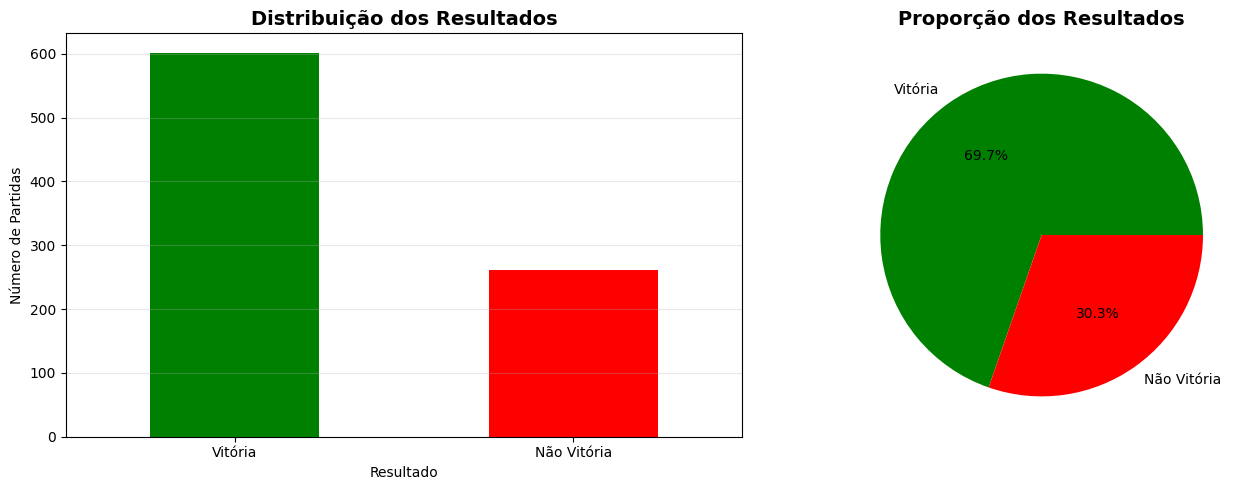

Gráfico gerado


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_features['target_label'] = df_features['target'].map({1: 'Vitória', 0: 'Não Vitória'})

df_features['target_label'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Distribuição dos Resultados', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Resultado')
axes[0].set_ylabel('Número de Partidas')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', alpha=0.3)

df_features['target_label'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['green', 'red'])
axes[1].set_title('Proporção dos Resultados', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('distribuicao_resultados.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico gerado")

## 5. Preparação de Features para Modelagem

**Nota importante:** Sem balanceamento SMOTE - usaremos a distribuição natural das classes

In [ ]:
# Preparar dados para modelagem
colunas_remover = ['target', 'temporada', 'data', 'target_label']

# Remover colunas de nomes e posições (não numéricas)
colunas_remover += [col for col in df_features.columns if '_name' in col or '_position' in col]

# Selecionar apenas features numéricas
X = df_features.drop(colunas_remover, axis=1, errors='ignore')
y = df_features['target']

print(f"Features antes da filtragem: {X.shape}")

# Garantir que apenas colunas numéricas sejam usadas
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"Removendo {len(non_numeric)} colunas não numéricas: {non_numeric[:5]}...")
    X = X.select_dtypes(include=[np.number])

# Preencher valores ausentes
X = X.fillna(X.median())

y_encoded = y.values

print(f"\nFeatures finais: {X.shape}")
print(f"\nTarget binário:")
vitorias = (y_encoded == 1).sum()
nao_vitorias = (y_encoded == 0).sum()
print(f"  Vitórias: {vitorias} ({vitorias/len(y_encoded)*100:.1f}%)")
print(f"  Não Vitórias: {nao_vitorias} ({nao_vitorias/len(y_encoded)*100:.1f}%)")

Features antes da filtragem: (864, 276)

Features finais: (864, 276)

Target binário:
  Vitórias: 602 (69.7%)
  Não Vitórias: 262 (30.3%)


## 6. Normalização e Divisão dos Dados

**Divisão: 60% Treino | 20% Validação | 20% Teste**

In [ ]:
# Normalizar features
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(['Não Vitória', 'Vitória'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"Features normalizadas: {X_scaled.shape}")

# Divisão: 60% treino, 20% validação, 20% teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.20,
    random_state=RANDOM_STATE, stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25,  # 0.25 de 80% = 20% do total
    random_state=RANDOM_STATE, stratify=y_temp
)

print(f"\nDivisão dos dados (sem balanceamento):")
print(f"Treino: {len(X_train):,} ({len(X_train)/len(X_scaled)*100:.1f}%)")
print(f"Validação: {len(X_val):,} ({len(X_val)/len(X_scaled)*100:.1f}%)")
print(f"Teste: {len(X_test):,} ({len(X_test)/len(X_scaled)*100:.1f}%)")

print(f"\nDistribuição das classes:")
print(f"  Treino: {dict(zip([0, 1], np.bincount(y_train)))}")
print(f"  Validação: {dict(zip([0, 1], np.bincount(y_val)))}")
print(f"  Teste: {dict(zip([0, 1], np.bincount(y_test)))}")

for label, count in zip([0, 1], np.bincount(y_train)):
    nome = 'Vitória' if label == 1 else 'Não Vitória'
    print(f"  {nome} (treino): {count:,} ({count/len(y_train)*100:.1f}%)")

X_train_final = X_train
y_train_final = y_train

Features normalizadas: (864, 276)

Divisão dos dados (sem balanceamento):
Treino: 518 (60.0%)
Validação: 173 (20.0%)
Teste: 173 (20.0%)

Distribuição das classes:
  Treino: {0: np.int64(157), 1: np.int64(361)}
  Validação: {0: np.int64(53), 1: np.int64(120)}
  Teste: {0: np.int64(52), 1: np.int64(121)}
  Não Vitória (treino): 157 (30.3%)
  Vitória (treino): 361 (69.7%)


## 7. Instalação de Bibliotecas Adicionais

In [ ]:
!pip install -q xgboost lightgbm catboost
print("Bibliotecas instaladas")

Bibliotecas instaladas


## 8. Treinamento dos Modelos

### 8.1 Random Forest

In [ ]:
print("Treinando Random Forest")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train_final, y_train_final)
print("Concluído")

Treinando Random Forest
Concluído


### 8.2 Gradient Boosting

In [ ]:
print("Treinando Gradient Boosting")

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_STATE
)

gb.fit(X_train_final, y_train_final)
print("Concluído")

Treinando Gradient Boosting
Concluído


### 8.3 SVM

In [ ]:
print("Treinando SVM")

svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=RANDOM_STATE,
    class_weight='balanced',
    probability=True
)

svm.fit(X_train_final, y_train_final)
print("Concluído")

Treinando SVM
Concluído


### 8.4 Regressão Logística

In [ ]:
print("Treinando Regressão Logística")

lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    multi_class='multinomial'
)

lr.fit(X_train_final, y_train_final)
print("Concluído")

Treinando Regressão Logística
Concluído


### 8.5 MLP (Rede Neural)

In [ ]:
print("Treinando MLP")

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1
)

mlp.fit(X_train_final, y_train_final)
print("Concluído")

Treinando MLP
Concluído


### 8.6 XGBoost

In [ ]:
print("Treinando XGBoost")

import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=-1
)

xgb_model.fit(X_train_final, y_train_final)
print("Concluído")

Treinando XGBoost
Concluído


### 8.7 LightGBM

In [ ]:
print("Treinando LightGBM")

import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train_final, y_train_final)
print("Concluído")

Treinando LightGBM
Concluído


### 8.8 CatBoost

In [ ]:
print("Treinando CatBoost")

from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=7,
    random_state=RANDOM_STATE,
    verbose=False,
    thread_count=-1
)

cat_model.fit(X_train_final, y_train_final)
print("Concluído")

Treinando CatBoost
Concluído


## 9. Avaliação dos Modelos

In [ ]:
def avaliar_modelo(modelo, X_test, y_test, label_encoder, nome_modelo, X_val=None, y_val=None):
    print(f"\nAvaliação: {nome_modelo}")

    # Avaliação no conjunto de teste
    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)

    print(f"\n=== CONJUNTO DE TESTE ===")
    print(f"Acurácia: {accuracy:.4f}")
    print(f"Precisão: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Avaliação no conjunto de validação (se fornecido)
    if X_val is not None and y_val is not None:
        y_val_pred = modelo.predict(X_val)
        val_accuracy = accuracy_score(y_val, y_val_pred)
        val_precision = precision_score(y_val, y_val_pred, average='binary', zero_division=0)
        val_recall = recall_score(y_val, y_val_pred, average='binary', zero_division=0)
        val_f1 = f1_score(y_val, y_val_pred, average='binary', zero_division=0)

        print(f"\n=== CONJUNTO DE VALIDAÇÃO ===")
        print(f"Acurácia: {val_accuracy:.4f}")
        print(f"Precisão: {val_precision:.4f}")
        print(f"Recall: {val_recall:.4f}")
        print(f"F1-Score: {val_f1:.4f}")

    target_names = ['Não Vitória', 'Vitória']
    print("\nRelatório de Classificação (Teste):")
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names,
                cbar_kws={'label': 'Contagem'})
    plt.title(f'Matriz de Confusão - {nome_modelo}', fontsize=14, fontweight='bold')
    plt.ylabel('Real', fontsize=12)
    plt.xlabel('Predito', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{nome_modelo.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    resultado = {
        'modelo': nome_modelo,
        'accuracy_test': accuracy,
        'precision_test': precision,
        'recall_test': recall,
        'f1_score_test': f1
    }

    if X_val is not None and y_val is not None:
        resultado['accuracy_val'] = val_accuracy
        resultado['precision_val'] = val_precision
        resultado['recall_val'] = val_recall
        resultado['f1_score_val'] = val_f1

    return resultado

print("Função de avaliação criada")

Função de avaliação criada


Avaliando modelos

Avaliação: Random Forest

=== CONJUNTO DE TESTE ===
Acurácia: 0.6763
Precisão: 0.7211
Recall: 0.8760
F1-Score: 0.7910

=== CONJUNTO DE VALIDAÇÃO ===
Acurácia: 0.6590
Precisão: 0.7133
Recall: 0.8500
F1-Score: 0.7757

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

 Não Vitória       0.42      0.21      0.28        52
     Vitória       0.72      0.88      0.79       121

    accuracy                           0.68       173
   macro avg       0.57      0.54      0.54       173
weighted avg       0.63      0.68      0.64       173



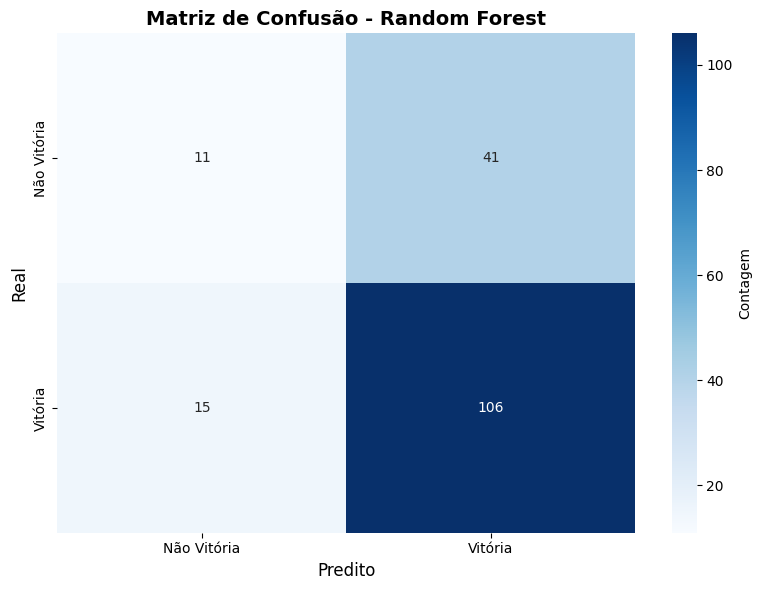


Avaliação: Gradient Boosting

=== CONJUNTO DE TESTE ===
Acurácia: 0.6127
Precisão: 0.6957
Recall: 0.7934
F1-Score: 0.7413

=== CONJUNTO DE VALIDAÇÃO ===
Acurácia: 0.6647
Precisão: 0.7246
Recall: 0.8333
F1-Score: 0.7752

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

 Não Vitória       0.29      0.19      0.23        52
     Vitória       0.70      0.79      0.74       121

    accuracy                           0.61       173
   macro avg       0.49      0.49      0.49       173
weighted avg       0.57      0.61      0.59       173



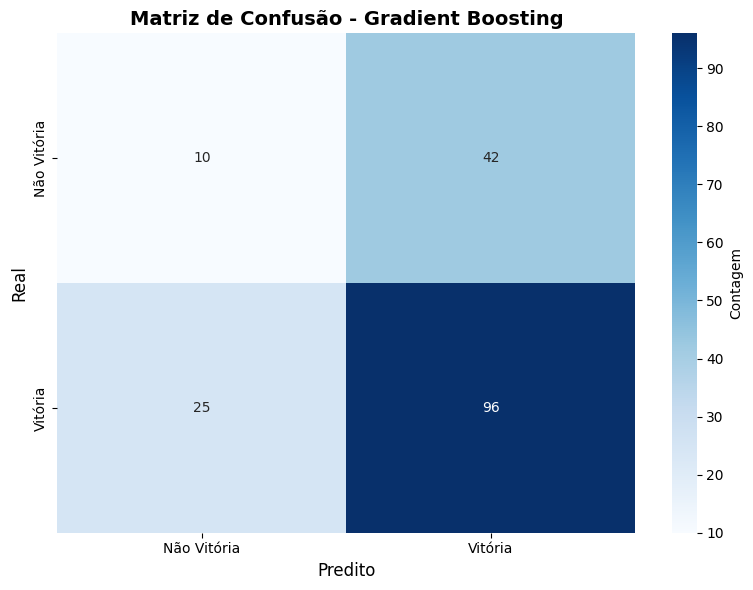


Avaliação: SVM

=== CONJUNTO DE TESTE ===
Acurácia: 0.6012
Precisão: 0.7453
Recall: 0.6529
F1-Score: 0.6960

=== CONJUNTO DE VALIDAÇÃO ===
Acurácia: 0.6127
Precisão: 0.7304
Recall: 0.7000
F1-Score: 0.7149

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

 Não Vitória       0.37      0.48      0.42        52
     Vitória       0.75      0.65      0.70       121

    accuracy                           0.60       173
   macro avg       0.56      0.57      0.56       173
weighted avg       0.63      0.60      0.61       173



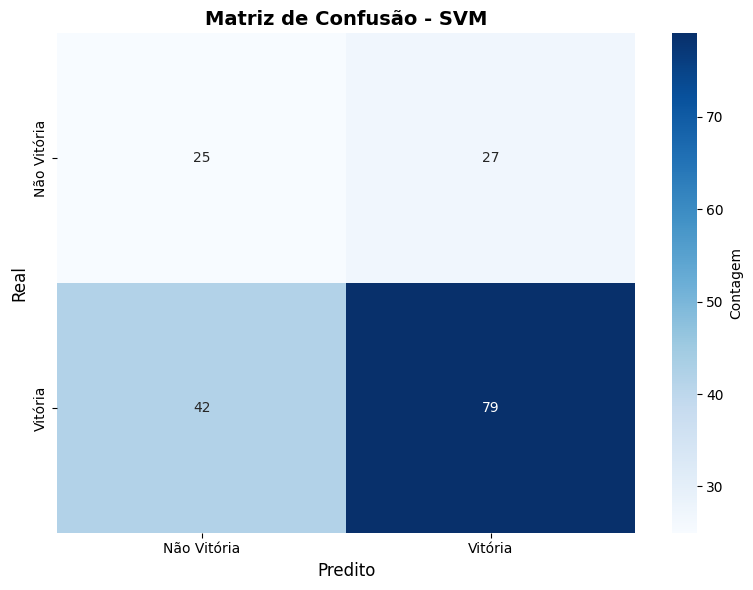


Avaliação: Regressão Logística

=== CONJUNTO DE TESTE ===
Acurácia: 0.6069
Precisão: 0.7524
Recall: 0.6529
F1-Score: 0.6991

=== CONJUNTO DE VALIDAÇÃO ===
Acurácia: 0.5607
Precisão: 0.6964
Recall: 0.6500
F1-Score: 0.6724

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

 Não Vitória       0.38      0.50      0.43        52
     Vitória       0.75      0.65      0.70       121

    accuracy                           0.61       173
   macro avg       0.57      0.58      0.57       173
weighted avg       0.64      0.61      0.62       173



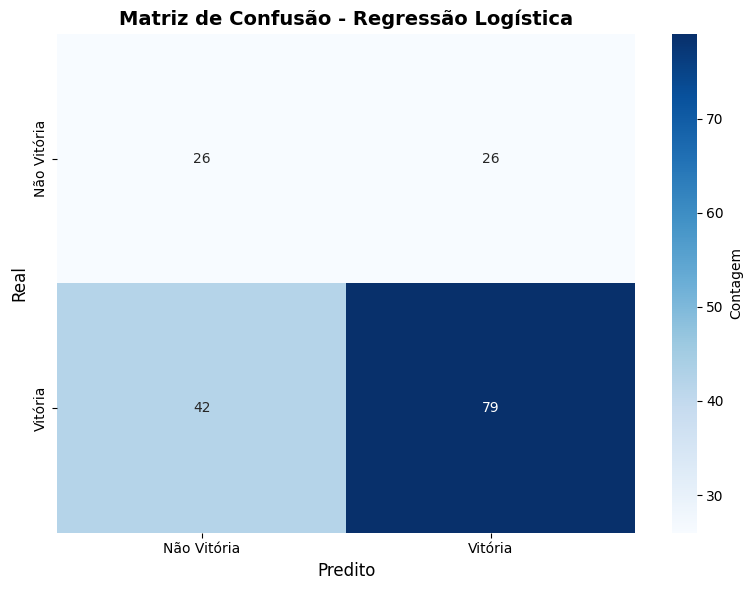


Avaliação: MLP

=== CONJUNTO DE TESTE ===
Acurácia: 0.6936
Precisão: 0.7000
Recall: 0.9835
F1-Score: 0.8179

=== CONJUNTO DE VALIDAÇÃO ===
Acurácia: 0.6821
Precisão: 0.6901
Recall: 0.9833
F1-Score: 0.8110

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

 Não Vitória       0.33      0.02      0.04        52
     Vitória       0.70      0.98      0.82       121

    accuracy                           0.69       173
   macro avg       0.52      0.50      0.43       173
weighted avg       0.59      0.69      0.58       173



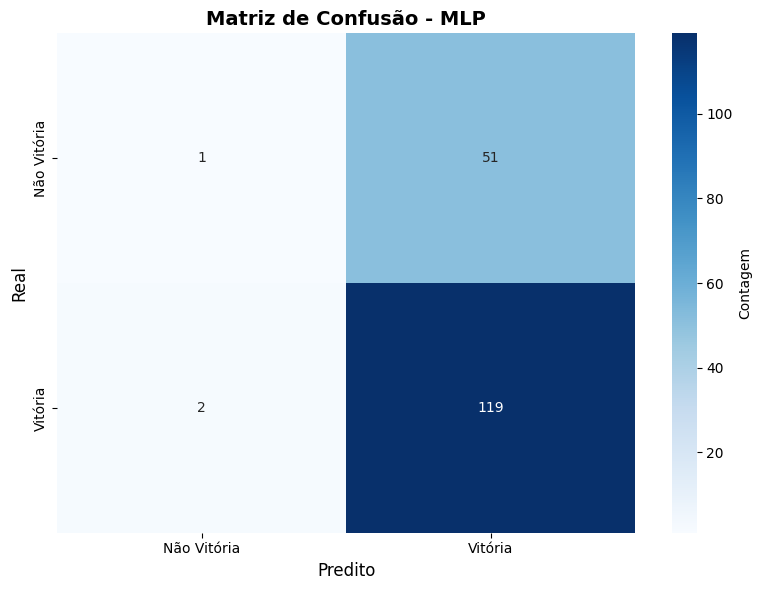


Avaliação: XGBoost

=== CONJUNTO DE TESTE ===
Acurácia: 0.6532
Precisão: 0.7133
Recall: 0.8430
F1-Score: 0.7727

=== CONJUNTO DE VALIDAÇÃO ===
Acurácia: 0.6358
Precisão: 0.7021
Recall: 0.8250
F1-Score: 0.7586

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

 Não Vitória       0.37      0.21      0.27        52
     Vitória       0.71      0.84      0.77       121

    accuracy                           0.65       173
   macro avg       0.54      0.53      0.52       173
weighted avg       0.61      0.65      0.62       173



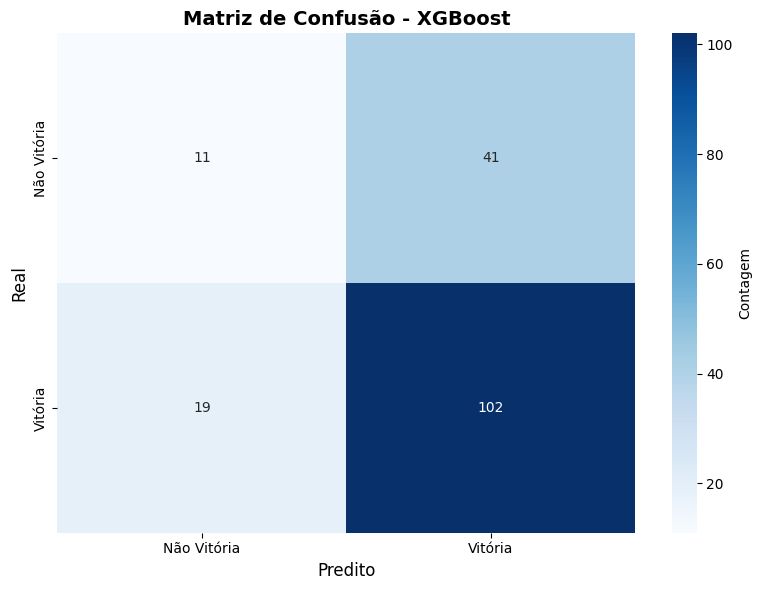


Avaliação: LightGBM

=== CONJUNTO DE TESTE ===
Acurácia: 0.6532
Precisão: 0.7163
Recall: 0.8347
F1-Score: 0.7710

=== CONJUNTO DE VALIDAÇÃO ===
Acurácia: 0.6069
Precisão: 0.6940
Recall: 0.7750
F1-Score: 0.7323

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

 Não Vitória       0.38      0.23      0.29        52
     Vitória       0.72      0.83      0.77       121

    accuracy                           0.65       173
   macro avg       0.55      0.53      0.53       173
weighted avg       0.61      0.65      0.63       173



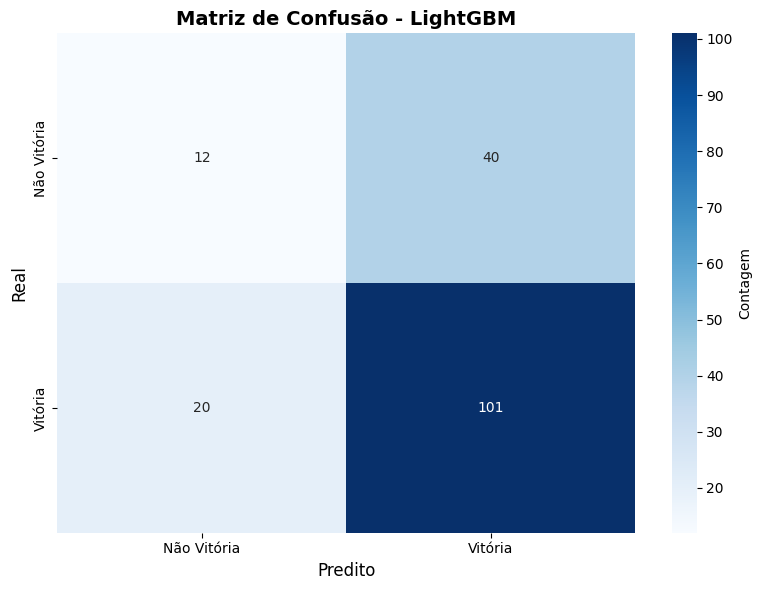


Avaliação: CatBoost

=== CONJUNTO DE TESTE ===
Acurácia: 0.6358
Precisão: 0.6986
Recall: 0.8430
F1-Score: 0.7640

=== CONJUNTO DE VALIDAÇÃO ===
Acurácia: 0.6705
Precisão: 0.7143
Recall: 0.8750
F1-Score: 0.7865

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

 Não Vitória       0.30      0.15      0.20        52
     Vitória       0.70      0.84      0.76       121

    accuracy                           0.64       173
   macro avg       0.50      0.50      0.48       173
weighted avg       0.58      0.64      0.60       173



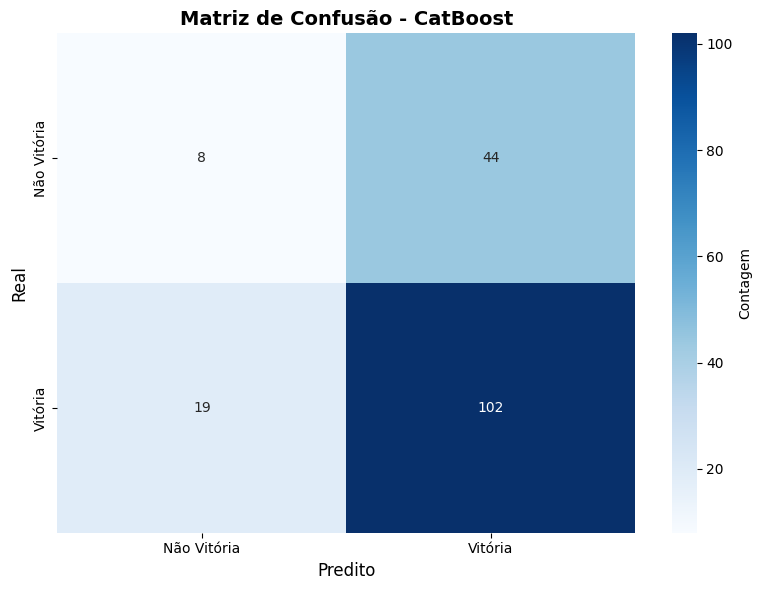


Avaliação completa


In [ ]:
print("Avaliando modelos")

modelos = {
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'SVM': svm,
    'Regressão Logística': lr,
    'MLP': mlp,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'CatBoost': cat_model
}

resultados = []

for nome, modelo in modelos.items():
    resultado = avaliar_modelo(modelo, X_test, y_test, label_encoder, nome, X_val, y_val)
    resultados.append(resultado)

print("\nAvaliação completa")

## 10. Comparação de Resultados

In [ ]:
df_resultados = pd.DataFrame(resultados)
print("\nComparação dos Modelos:")
print(df_resultados.to_string(index=False))

melhor_modelo = df_resultados.loc[df_resultados['accuracy_test'].idxmax()]
print(f"\nMelhor modelo: {melhor_modelo['modelo']}")
print(f"Acurácia (Teste): {melhor_modelo['accuracy_test']:.4f}")


Comparação dos Modelos:
             modelo  accuracy_test  precision_test  recall_test  f1_score_test  accuracy_val  precision_val  recall_val  f1_score_val
      Random Forest       0.676301        0.721088     0.876033       0.791045      0.658960       0.713287    0.850000      0.775665
  Gradient Boosting       0.612717        0.695652     0.793388       0.741313      0.664740       0.724638    0.833333      0.775194
                SVM       0.601156        0.745283     0.652893       0.696035      0.612717       0.730435    0.700000      0.714894
Regressão Logística       0.606936        0.752381     0.652893       0.699115      0.560694       0.696429    0.650000      0.672414
                MLP       0.693642        0.700000     0.983471       0.817869      0.682081       0.690058    0.983333      0.810997
            XGBoost       0.653179        0.713287     0.842975       0.772727      0.635838       0.702128    0.825000      0.758621
           LightGBM       0.653179   

## 11. Análise de Importância de Features


Análise de Importância - RANDOM FOREST


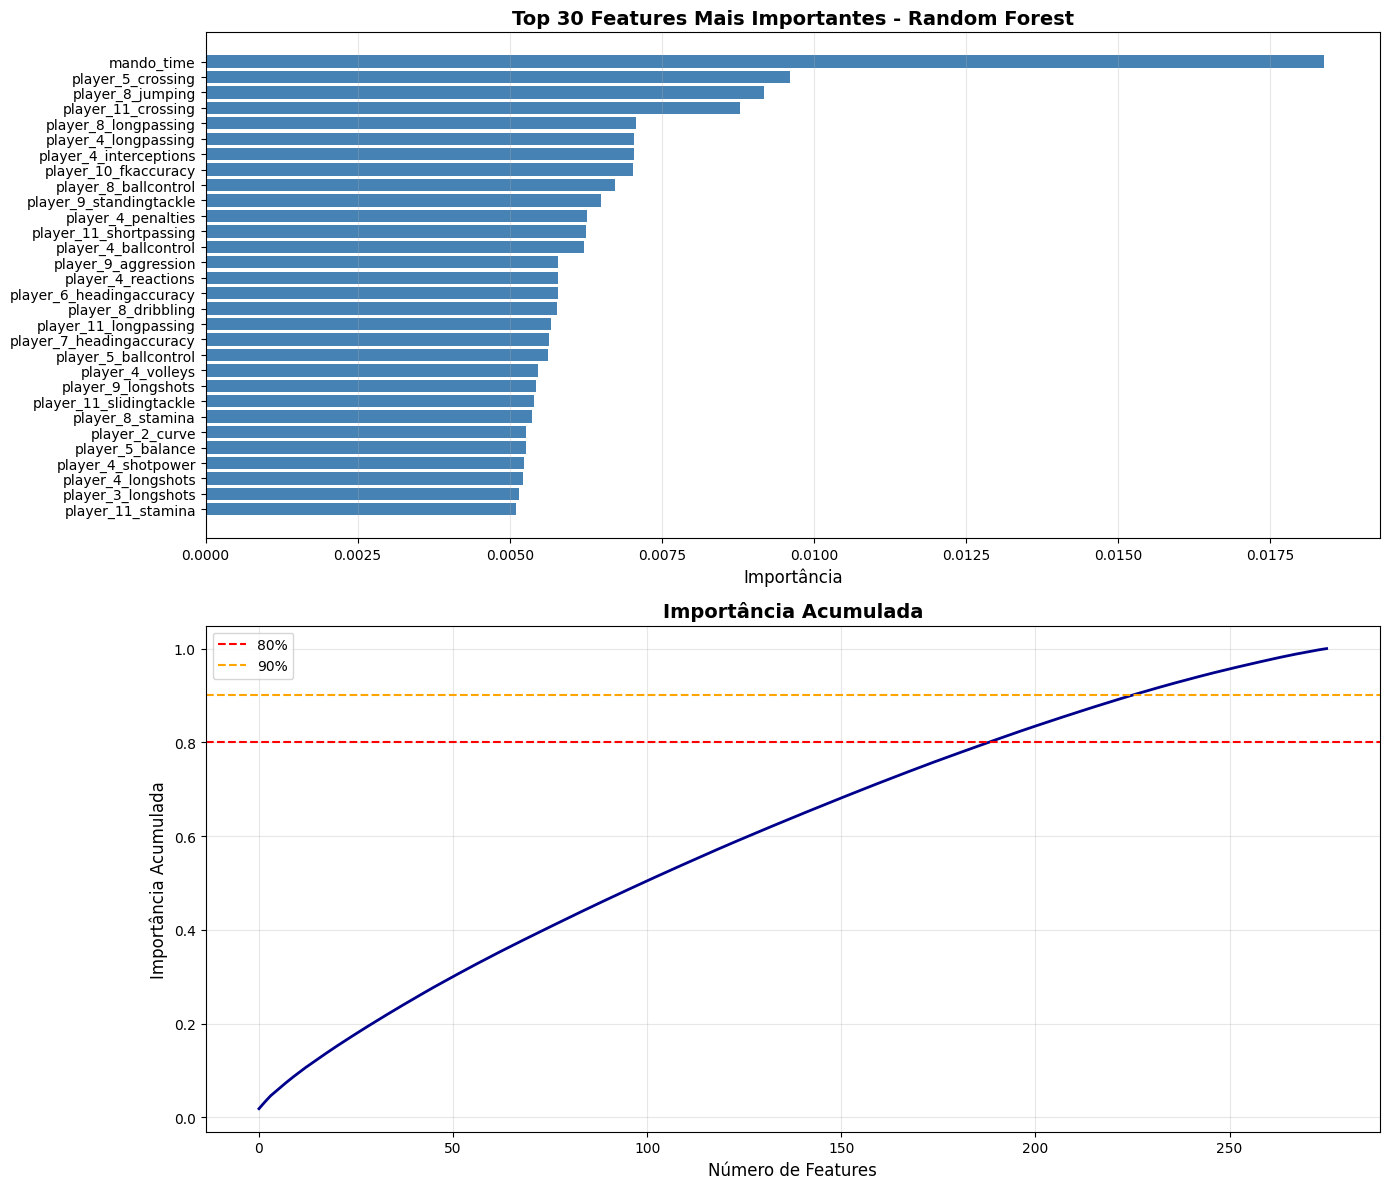


Análise por categoria:

Ofensivo:
  Importância Total: 0.1589
  Top 3:
    player_5_crossing: 0.0096
    player_11_crossing: 0.0088
    player_8_dribbling: 0.0058

Defensivo:
  Importância Total: 0.1610
  Top 3:
    player_4_interceptions: 0.0070
    player_9_standingtackle: 0.0065
    player_9_aggression: 0.0058

Físico:
  Importância Total: 0.1356
  Top 3:
    player_8_jumping: 0.0092
    player_8_stamina: 0.0054
    player_11_stamina: 0.0051

Técnico:
  Importância Total: 0.1526
  Top 3:
    player_8_longpassing: 0.0071
    player_4_longpassing: 0.0071
    player_11_shortpassing: 0.0062

Features com importância < 0.001: 0
189 features explicam 80% da importância
Total: 276 features


In [ ]:
def analisar_importancia_features(modelo, X_treino, nome_modelo='Random Forest', top_n=30):
    print(f"\nAnálise de Importância - {nome_modelo.upper()}")

    importances = modelo.feature_importances_
    feature_names = X_treino.columns

    df_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)

    df_top = df_importance.head(top_n)

    fig, axes = plt.subplots(2, 1, figsize=(14, 12))

    axes[0].barh(range(len(df_top)), df_top['importance'].values, color='steelblue')
    axes[0].set_yticks(range(len(df_top)))
    axes[0].set_yticklabels(df_top['feature'].values)
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Importância', fontsize=12)
    axes[0].set_title(f'Top {top_n} Features Mais Importantes - {nome_modelo}',
                     fontsize=14, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

    df_importance_sorted = df_importance.sort_values('importance', ascending=False)
    cumsum = df_importance_sorted['importance'].cumsum()

    axes[1].plot(range(len(cumsum)), cumsum, linewidth=2, color='darkblue')
    axes[1].axhline(y=0.8, color='red', linestyle='--', label='80%')
    axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90%')
    axes[1].set_xlabel('Número de Features', fontsize=12)
    axes[1].set_ylabel('Importância Acumulada', fontsize=12)
    axes[1].set_title('Importância Acumulada', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'importancia_features_{nome_modelo.replace(" ", "_").lower()}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    print("\nAnálise por categoria:")

    categorias = {
        'Ofensivo': ['finishing', 'dribbling', 'crossing', 'shot_power', 'positioning',
                     'volleys', 'long_shots', 'poder_fogo', 'ofensivo'],
        'Defensivo': ['marking', 'tackle', 'interceptions', 'aggression', 'defensivo',
                      'solidez_defensiva'],
        'Físico': ['sprint_speed', 'acceleration', 'stamina', 'strength', 'jumping',
                   'fisico', 'intensidade'],
        'Técnico': ['ball_control', 'passing', 'vision', 'reactions', 'tecnico',
                    'qualidade_tecnica'],
        'Geral': ['overall_rating'],
        'Comparativo': ['_diff', '_ratio'],
        'Sinergia': ['box_to_box', 'diversidade', 'homogeneidade', 'estrelas']
    }

    for categoria, palavras_chave in categorias.items():
        features_categoria = df_importance[
            df_importance['feature'].str.contains('|'.join(palavras_chave), case=False, na=False)
        ]

        if len(features_categoria) > 0:
            importancia_total = features_categoria['importance'].sum()
            top_3 = features_categoria.head(3)

            print(f"\n{categoria}:")
            print(f"  Importância Total: {importancia_total:.4f}")
            print(f"  Top 3:")
            for _, row in top_3.iterrows():
                print(f"    {row['feature']}: {row['importance']:.4f}")

    features_irrelevantes = df_importance[df_importance['importance'] < 0.001]
    print(f"\nFeatures com importância < 0.001: {len(features_irrelevantes)}")

    num_features_80 = (cumsum <= 0.8).sum() + 1
    print(f"{num_features_80} features explicam 80% da importância")
    print(f"Total: {len(df_importance)} features")

    return df_importance

# Analisar Random Forest
df_importance_rf = analisar_importancia_features(rf, X_train_final, 'Random Forest', top_n=30)

## 12. Identificação do Melhor Jogador

In [ ]:
print("Identificando o melhor jogador do time")

# Preparar lista de exclusões
colunas_excluir = ['target', 'temporada', 'data', 'mando_time', 'target_label']
colunas_excluir += [col for col in df_features.columns if '_name' in col or '_position' in col]

feature_cols = [col for col in df_features.columns if col not in colunas_excluir]
numeric_df = df_features[feature_cols].select_dtypes(include=[np.number])
feature_cols = numeric_df.columns.tolist()

print(f"Total de features numéricas: {len(feature_cols)}")

# Obter importâncias do modelo
importances = rf.feature_importances_
feature_importance_dict = dict(zip(feature_cols, importances))

jogador_importancia = {}

print("Calculando importância de cada jogador...")

# Extrair nomes únicos dos jogadores
colunas_nomes = [col for col in df_features.columns if '_name' in col]

for _, row in df_features.iterrows():
    for i in range(1, 12):
        # Tentar encontrar o nome do jogador
        nome_col = f'player_{i}_name'

        if nome_col not in df_features.columns:
            continue

        player_name = row[nome_col]

        if pd.isna(player_name) or player_name == '':
            continue

        # Calcular importância total das features deste jogador
        importancia_total = 0
        num_features = 0

        for feature_name, importance in feature_importance_dict.items():
            if f'player_{i}_' in feature_name:
                importancia_total += importance
                num_features += 1

        if player_name not in jogador_importancia:
            jogador_importancia[player_name] = {
                'importancia_total': 0,
                'importancia_media': 0,
                'partidas': 0,
                'vitorias': 0
            }

        jogador_importancia[player_name]['importancia_total'] += importancia_total
        jogador_importancia[player_name]['partidas'] += 1
        jogador_importancia[player_name]['vitorias'] += row['target']

        if num_features > 0:
            jogador_importancia[player_name]['importancia_media'] = (
                jogador_importancia[player_name]['importancia_total'] /
                jogador_importancia[player_name]['partidas']
            )

if len(jogador_importancia) == 0:
    print("\nNão foi possível identificar jogadores individuais no dataset.")
    print("O dataset pode não conter colunas de nomes de jogadores.")
else:
    df_jogadores = pd.DataFrame.from_dict(jogador_importancia, orient='index')
    df_jogadores['taxa_vitoria'] = df_jogadores['vitorias'] / df_jogadores['partidas']
    df_jogadores = df_jogadores.sort_values('importancia_total', ascending=False)

    df_jogadores_filtrado = df_jogadores[df_jogadores['partidas'] >= 3]

    print(f"\nAnálise concluída: {len(df_jogadores_filtrado)} jogadores com 3+ partidas")

    if len(df_jogadores_filtrado) > 0:
        print("\nTOP 15 JOGADORES:")
        print(f"{'Jogador':<30} {'Partidas':>8} {'Importância':>12} {'Taxa Vitória':>12}")

        for idx, (jogador, stats) in enumerate(df_jogadores_filtrado.head(15).iterrows(), 1):
            print(f"{idx:2d}. {jogador:<27} {stats['partidas']:>8.0f} "
                  f"{stats['importancia_total']:>12.6f} {stats['taxa_vitoria']:>11.1%}")

        melhor_jogador = df_jogadores_filtrado.index[0]
        stats_melhor = df_jogadores_filtrado.iloc[0]

        print(f"\nMelhor Jogador: {melhor_jogador}")
        print(f"Partidas: {stats_melhor['partidas']:.0f}")
        print(f"Vitórias: {stats_melhor['vitorias']:.0f}")
        print(f"Taxa de Vitória: {stats_melhor['taxa_vitoria']:.1%}")
        print(f"Importância: {stats_melhor['importancia_total']:.6f}")

        df_jogadores_filtrado.to_csv('ranking_jogadores.csv')
        print("\nRanking salvo: ranking_jogadores.csv")
    else:
        print("Nenhum jogador encontrado com o mínimo de partidas.")

Identificando o melhor jogador do time
Total de features numéricas: 275
Calculando importância de cada jogador...

Análise concluída: 151 jogadores com 3+ partidas

TOP 15 JOGADORES:
Jogador                        Partidas  Importância Taxa Vitória
 1. Sergio Busquets                  552    52.966819       69.2%
 2. Piqué                            478    48.109131       69.2%
 3. Lionel Messi                     504    45.566839       73.0%
 4. Jordi Alba                       389    37.807025       67.6%
 5. A. Iniesta                       282    28.520662       73.8%
 6. Dani Alves                       282    25.809692       75.2%
 7. Javier Mascherano                238    24.202491       74.4%
 8. Sergi Roberto                    227    23.479652       65.6%
 9. Luis Suárez                      243    21.408492       72.0%
10. Frenkie de Jong                  232    20.912238       62.1%
11. Ivan Rakitić                     221    19.929559       72.9%
12. Xavi                 

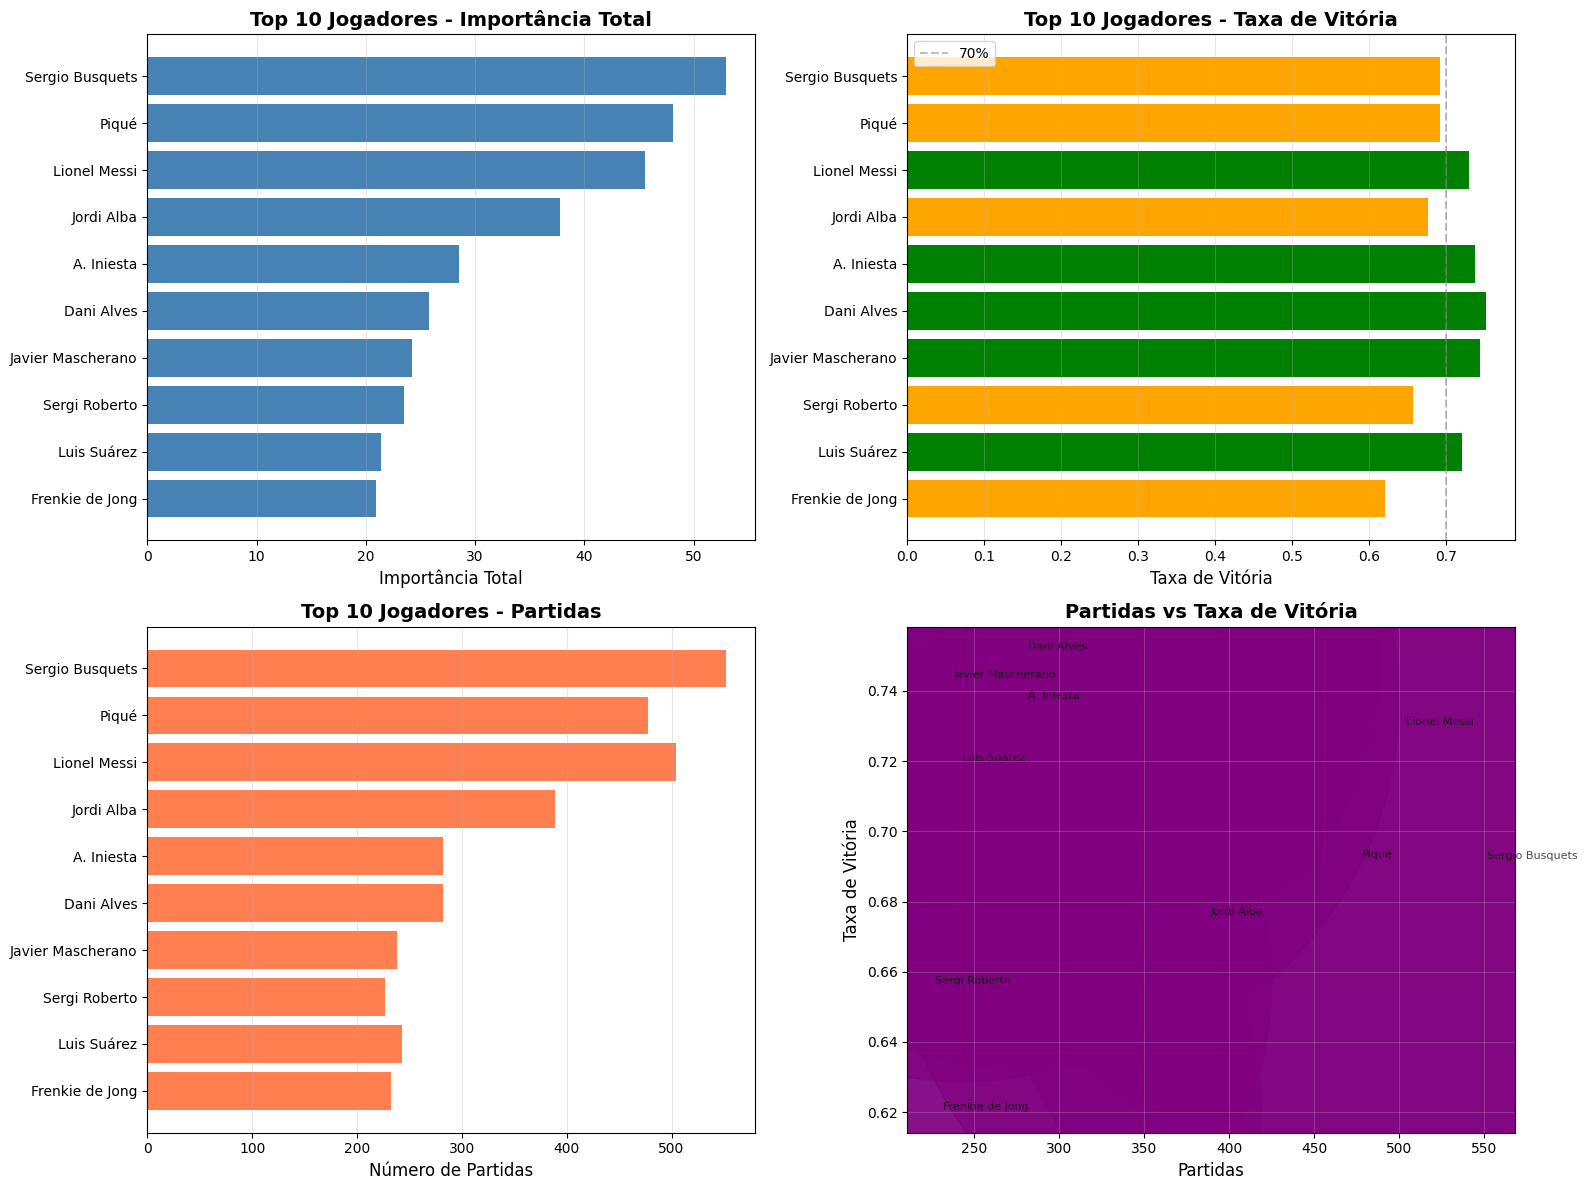

Visualização gerada


In [ ]:
# Visualização da análise de jogadores (apenas se houver dados)
if 'df_jogadores_filtrado' in locals() and len(df_jogadores_filtrado) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    top_10 = df_jogadores_filtrado.head(10)

    axes[0, 0].barh(range(len(top_10)), top_10['importancia_total'].values, color='steelblue')
    axes[0, 0].set_yticks(range(len(top_10)))
    axes[0, 0].set_yticklabels(top_10.index)
    axes[0, 0].invert_yaxis()
    axes[0, 0].set_xlabel('Importância Total', fontsize=12)
    axes[0, 0].set_title('Top 10 Jogadores - Importância Total',
                         fontsize=14, fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3)

    colors_vit = ['green' if x > 0.7 else 'orange' if x > 0.5 else 'red'
                  for x in top_10['taxa_vitoria']]
    axes[0, 1].barh(range(len(top_10)), top_10['taxa_vitoria'].values, color=colors_vit)
    axes[0, 1].set_yticks(range(len(top_10)))
    axes[0, 1].set_yticklabels(top_10.index)
    axes[0, 1].invert_yaxis()
    axes[0, 1].set_xlabel('Taxa de Vitória', fontsize=12)
    axes[0, 1].set_title('Top 10 Jogadores - Taxa de Vitória',
                         fontsize=14, fontweight='bold')
    axes[0, 1].axvline(x=0.7, color='gray', linestyle='--', alpha=0.5, label='70%')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='x', alpha=0.3)

    axes[1, 0].barh(range(len(top_10)), top_10['partidas'].values, color='coral')
    axes[1, 0].set_yticks(range(len(top_10)))
    axes[1, 0].set_yticklabels(top_10.index)
    axes[1, 0].invert_yaxis()
    axes[1, 0].set_xlabel('Número de Partidas', fontsize=12)
    axes[1, 0].set_title('Top 10 Jogadores - Partidas',
                         fontsize=14, fontweight='bold')
    axes[1, 0].grid(axis='x', alpha=0.3)

    axes[1, 1].scatter(top_10['partidas'], top_10['taxa_vitoria'],
                       s=top_10['importancia_total']*10000, alpha=0.6, color='purple')

    for idx, (jogador, stats) in enumerate(top_10.iterrows()):
        axes[1, 1].annotate(jogador,
                            (stats['partidas'], stats['taxa_vitoria']),
                            fontsize=8, alpha=0.7)

    axes[1, 1].set_xlabel('Partidas', fontsize=12)
    axes[1, 1].set_ylabel('Taxa de Vitória', fontsize=12)
    axes[1, 1].set_title('Partidas vs Taxa de Vitória',
                         fontsize=14, fontweight='bold')
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('analise_jogadores.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Visualização gerada")
else:
    print("Visualização de jogadores não disponível (dados insuficientes)")

## 13. Experimentos Comparativos de Representação de Features

In [ ]:
def preparar_dados_para_experimentos(df):
    """
    Prepara os dados para os experimentos de features.
    """
    df_prep = df.copy()
    print(f"Dados preparados: {df_prep.shape}")

    player_cols = [col for col in df_prep.columns if 'player_' in col]
    print(f"Colunas de jogadores encontradas: {len(player_cols)}")

    return df_prep

def preparar_dataset_experimento1(df):
    """
    Experimento 1: Usa atributos agregados dos jogadores (ex: médias).
    """
    feature_cols = []

    for i in range(1, 12):
        cols = [col for col in df.columns if f'player_{i}_' in col]
        numeric_cols = [col for col in cols if '_name' not in col and '_position' not in col]

        if len(numeric_cols) > 0:
            for col in numeric_cols[:10]:  # Limitar a 10 atributos por jogador
                if col in df.columns:
                    feature_cols.append(col)

    X = df[feature_cols].copy()
    y = df['target'].copy()

    print(f"Experimento 1: {len(feature_cols)} features selecionadas")

    return X, y

def preparar_dataset_experimento2(df):
    """
    Experimento 2: Usa todos os atributos individuais disponíveis.
    """
    colunas_excluir = ['target', 'temporada', 'data', 'mando_time', 'target_label']
    colunas_excluir += [col for col in df.columns if '_name' in col or '_position' in col]

    X = df.drop(colunas_excluir, axis=1, errors='ignore')
    X = X.select_dtypes(include=[np.number])
    y = df['target'].copy()

    print(f"Experimento 2: {X.shape[1]} features (todos atributos)")

    return X, y

def preparar_dataset_experimento3(df):
    """
    Experimento 3: Usa médias de atributos por jogador.
    """
    features_dict = {}

    for i in range(1, 12):
        cols = [col for col in df.columns if f'player_{i}_' in col]
        numeric_cols = [col for col in cols if '_name' not in col and '_position' not in col and df[col].dtype in ['float64', 'int64']]

        if len(numeric_cols) > 0:
            features_dict[f'player_{i}_mean'] = df[numeric_cols].mean(axis=1)

    X = pd.DataFrame(features_dict)
    y = df['target'].copy()

    print(f"Experimento 3: {X.shape[1]} features (médias por jogador)")

    return X, y

def preparar_dataset_experimento4(df):
    """
    Experimento 4: Usa atributos específicos selecionados.
    """
    atributos_chave = ['gkdiving', 'gkhandling', 'gkkicking', 'gkpositioning', 'gkreflexes',
                       'crossing', 'finishing', 'shortpassing', 'dribbling', 'curve',
                       'longpassing', 'ballcontrol', 'acceleration', 'sprintspeed',
                       'agility', 'reactions', 'shotpower', 'stamina', 'strength']

    feature_cols = []
    for i in range(1, 12):
        for attr in atributos_chave:
            col = f'player_{i}_{attr}'
            if col in df.columns:
                feature_cols.append(col)

    X = df[feature_cols].copy() if feature_cols else df.select_dtypes(include=[np.number]).iloc[:, :50]
    y = df['target'].copy()

    print(f"Experimento 4: {X.shape[1]} features (atributos-chave)")

    return X, y

print("Funções de preparação criadas")

Funções de preparação criadas


In [ ]:
def treinar_avaliar_experimento(X, y, nome_experimento):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # Preencher valores ausentes
    X_train = X_train.fillna(X_train.median())
    X_train = X_train.fillna(0)

    X_test = X_test.fillna(X_test.median())
    X_test = X_test.fillna(0)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Sem balanceamento SMOTE
    X_train_balanced = X_train_scaled
    y_train_balanced = y_train

    modelos = {
        'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
        'XGBoost': xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=7, random_state=42, n_jobs=-1),
        'LightGBM': lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)
    }

    resultados = []

    for nome_modelo, modelo in modelos.items():
        modelo.fit(X_train_balanced, y_train_balanced)
        y_pred = modelo.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='binary', zero_division=0)
        rec = recall_score(y_test, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)

        resultados.append({
            'experimento': nome_experimento,
            'modelo': nome_modelo,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'num_features': X.shape[1]
        })

    return pd.DataFrame(resultados)

print("Função de treinamento criada")

Função de treinamento criada


### Experimento 1: Atributos Agregados

In [ ]:
print("Executando Experimento 1: Atributos Agregados")
print("="*80)

df_exp = preparar_dados_para_experimentos(df_features)
X_exp1, y_exp1 = preparar_dataset_experimento1(df_exp)

print(f"Shape dos dados: {X_exp1.shape}")
print()

resultados_exp1 = treinar_avaliar_experimento(X_exp1, y_exp1, "Experimento 1")

print("\nResultados do Experimento 1:")
print(resultados_exp1[['modelo', 'accuracy', 'precision', 'recall', 'f1']].to_string(index=False))
print()
print(f"Acurácia média: {resultados_exp1['accuracy'].mean():.4f}")
print(f"F1-Score médio: {resultados_exp1['f1'].mean():.4f}")

Executando Experimento 1: Atributos Agregados
Dados preparados: (864, 312)
Colunas de jogadores encontradas: 307
Experimento 1: 105 features selecionadas
Shape dos dados: (864, 105)


Resultados do Experimento 1:
           modelo  accuracy  precision   recall       f1
    Random Forest  0.635838   0.693333 0.859504 0.767528
Gradient Boosting  0.635838   0.701389 0.834711 0.762264
          XGBoost  0.606936   0.690647 0.793388 0.738462
         LightGBM  0.612717   0.695652 0.793388 0.741313

Acurácia média: 0.6228
F1-Score médio: 0.7524


### Experimento 2: Todos os Atributos Individuais

In [ ]:
print("\nExecutando Experimento 2: Todos Atributos Individuais")
print("="*80)

X_exp2, y_exp2 = preparar_dataset_experimento2(df_exp)

print(f"Shape dos dados: {X_exp2.shape}")
print()

resultados_exp2 = treinar_avaliar_experimento(X_exp2, y_exp2, "Experimento 2")

print("\nResultados do Experimento 2:")
print(resultados_exp2[['modelo', 'accuracy', 'precision', 'recall', 'f1']].to_string(index=False))
print()
print(f"Acurácia média: {resultados_exp2['accuracy'].mean():.4f}")
print(f"F1-Score médio: {resultados_exp2['f1'].mean():.4f}")


Executando Experimento 2: Todos Atributos Individuais
Experimento 2: 275 features (todos atributos)
Shape dos dados: (864, 275)


Resultados do Experimento 2:
           modelo  accuracy  precision   recall       f1
    Random Forest  0.612717   0.680000 0.842975 0.752768
Gradient Boosting  0.635838   0.710145 0.809917 0.756757
          XGBoost  0.612717   0.690141 0.809917 0.745247
         LightGBM  0.612717   0.692857 0.801653 0.743295

Acurácia média: 0.6185
F1-Score médio: 0.7495


### Experimento 3: Médias por Jogador

In [ ]:
print("\nExecutando Experimento 3: Médias por Jogador")
print("="*80)

X_exp3, y_exp3 = preparar_dataset_experimento3(df_exp)

print(f"Shape dos dados: {X_exp3.shape}")
print()

resultados_exp3 = treinar_avaliar_experimento(X_exp3, y_exp3, "Experimento 3")

print("\nResultados do Experimento 3:")
print(resultados_exp3[['modelo', 'accuracy', 'precision', 'recall', 'f1']].to_string(index=False))
print()
print(f"Acurácia média: {resultados_exp3['accuracy'].mean():.4f}")
print(f"F1-Score médio: {resultados_exp3['f1'].mean():.4f}")


Executando Experimento 3: Médias por Jogador
Experimento 3: 11 features (médias por jogador)
Shape dos dados: (864, 11)


Resultados do Experimento 3:
           modelo  accuracy  precision   recall       f1
    Random Forest  0.676301   0.709677 0.909091 0.797101
Gradient Boosting  0.641618   0.697987 0.859504 0.770370
          XGBoost  0.635838   0.704225 0.826446 0.760456
         LightGBM  0.624277   0.702899 0.801653 0.749035

Acurácia média: 0.6445
F1-Score médio: 0.7692


### Experimento 4: Atributos-Chave Selecionados

In [ ]:
print("\nExecutando Experimento 4: Atributos-Chave Selecionados")
print("="*80)

X_exp4, y_exp4 = preparar_dataset_experimento4(df_exp)

print(f"Shape dos dados: {X_exp4.shape}")
print()

resultados_exp4 = treinar_avaliar_experimento(X_exp4, y_exp4, "Experimento 4")

print("\nResultados do Experimento 4:")
print(resultados_exp4[['modelo', 'accuracy', 'precision', 'recall', 'f1']].to_string(index=False))
print()
print(f"Acurácia média: {resultados_exp4['accuracy'].mean():.4f}")
print(f"F1-Score médio: {resultados_exp4['f1'].mean():.4f}")


Executando Experimento 4: Atributos-Chave Selecionados
Experimento 4: 145 features (atributos-chave)
Shape dos dados: (864, 145)


Resultados do Experimento 4:
           modelo  accuracy  precision   recall       f1
    Random Forest  0.653179   0.694268 0.900826 0.784173
Gradient Boosting  0.641618   0.709220 0.826446 0.763359
          XGBoost  0.595376   0.683453 0.785124 0.730769
         LightGBM  0.595376   0.694656 0.752066 0.722222

Acurácia média: 0.6214
F1-Score médio: 0.7501


### Comparação entre Experimentos

In [ ]:
df_todos_experimentos = pd.concat([
    resultados_exp1,
    resultados_exp2,
    resultados_exp3,
    resultados_exp4
], ignore_index=True)

print("="*80)
print("COMPARAÇÃO ENTRE EXPERIMENTOS")
print("="*80)
print()

resumo_experimentos = df_todos_experimentos.groupby('experimento').agg({
    'accuracy': ['mean', 'std', 'min', 'max'],
    'f1': ['mean', 'std', 'min', 'max'],
    'num_features': 'first'
}).round(4)

print("Resumo Estatístico por Experimento:")
print(resumo_experimentos)
print()

melhor_por_experimento = df_todos_experimentos.loc[
    df_todos_experimentos.groupby('experimento')['accuracy'].idxmax()
]

print("Melhor Modelo por Experimento:")
print(melhor_por_experimento[['experimento', 'modelo', 'accuracy', 'f1', 'num_features']].to_string(index=False))
print()

print("Ranking de Experimentos por Acurácia Média:")
ranking = df_todos_experimentos.groupby('experimento')['accuracy'].mean().sort_values(ascending=False)
for i, (exp, acc) in enumerate(ranking.items(), 1):
    num_feat = df_todos_experimentos[df_todos_experimentos['experimento'] == exp]['num_features'].iloc[0]
    print(f"{i}. {exp} - Acurácia: {acc:.4f} ({num_feat} features)")

COMPARAÇÃO ENTRE EXPERIMENTOS

Resumo Estatístico por Experimento:
              accuracy                              f1                  \
                  mean     std     min     max    mean     std     min   
experimento                                                              
Experimento 1   0.6228  0.0152  0.6069  0.6358  0.7524  0.0146  0.7385   
Experimento 2   0.6185  0.0116  0.6127  0.6358  0.7495  0.0063  0.7433   
Experimento 3   0.6445  0.0224  0.6243  0.6763  0.7692  0.0205  0.7490   
Experimento 4   0.6214  0.0304  0.5954  0.6532  0.7501  0.0288  0.7222   

                      num_features  
                  max        first  
experimento                         
Experimento 1  0.7675          105  
Experimento 2  0.7568          275  
Experimento 3  0.7971           11  
Experimento 4  0.7842          145  

Melhor Modelo por Experimento:
  experimento            modelo  accuracy       f1  num_features
Experimento 1     Random Forest  0.635838 0.767528        

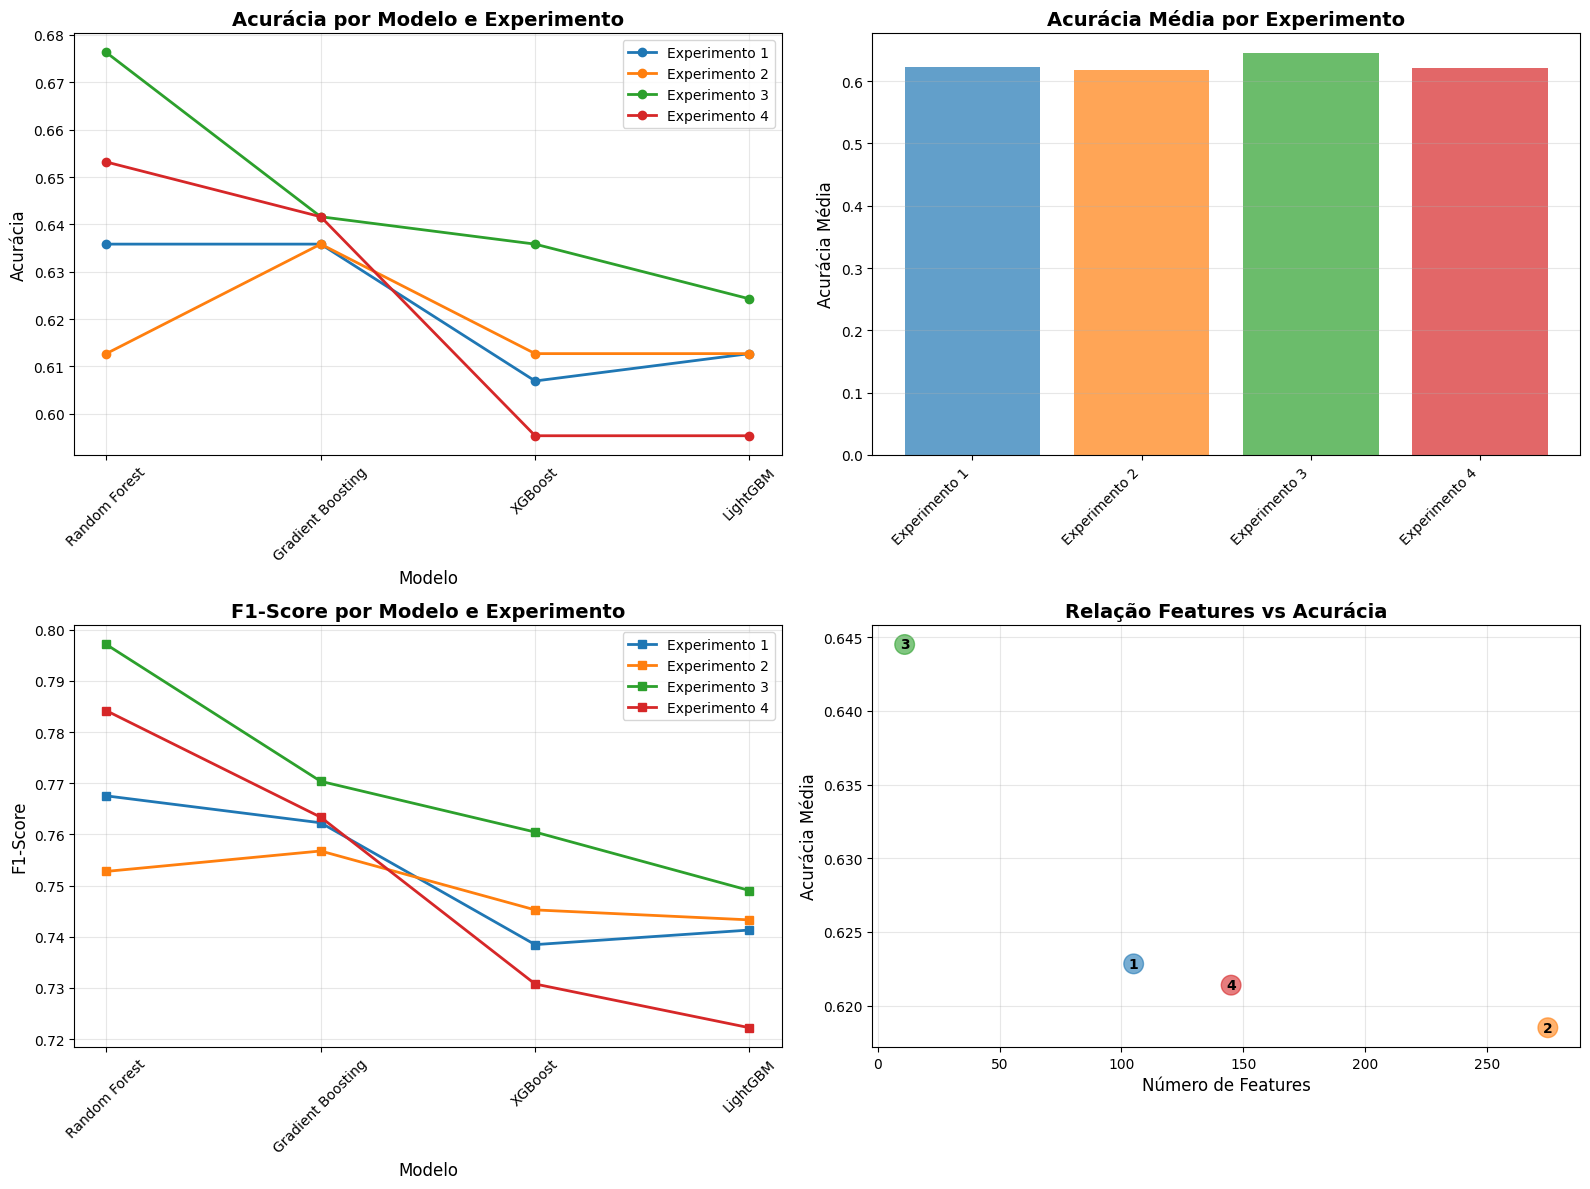

Visualização salva: comparacao_experimentos.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

experimentos_ordem = ['Experimento 1', 'Experimento 2', 'Experimento 3', 'Experimento 4']
cores_exp = {'Experimento 1': '#1f77b4', 'Experimento 2': '#ff7f0e',
             'Experimento 3': '#2ca02c', 'Experimento 4': '#d62728'}

for exp in experimentos_ordem:
    dados_exp = df_todos_experimentos[df_todos_experimentos['experimento'] == exp]
    axes[0, 0].plot(dados_exp['modelo'], dados_exp['accuracy'],
                    marker='o', label=exp, color=cores_exp[exp], linewidth=2)

axes[0, 0].set_xlabel('Modelo', fontsize=12)
axes[0, 0].set_ylabel('Acurácia', fontsize=12)
axes[0, 0].set_title('Acurácia por Modelo e Experimento', fontsize=14, fontweight='bold')
axes[0, 0].legend(loc='best', fontsize=10)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(alpha=0.3)

acuracias_medias = df_todos_experimentos.groupby('experimento')['accuracy'].mean()
axes[0, 1].bar(range(len(experimentos_ordem)),
               [acuracias_medias[exp] for exp in experimentos_ordem],
               color=[cores_exp[exp] for exp in experimentos_ordem],
               alpha=0.7)
axes[0, 1].set_xticks(range(len(experimentos_ordem)))
axes[0, 1].set_xticklabels(experimentos_ordem, rotation=45, ha='right')
axes[0, 1].set_ylabel('Acurácia Média', fontsize=12)
axes[0, 1].set_title('Acurácia Média por Experimento', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

for exp in experimentos_ordem:
    dados_exp = df_todos_experimentos[df_todos_experimentos['experimento'] == exp]
    axes[1, 0].plot(dados_exp['modelo'], dados_exp['f1'],
                    marker='s', label=exp, color=cores_exp[exp], linewidth=2)

axes[1, 0].set_xlabel('Modelo', fontsize=12)
axes[1, 0].set_ylabel('F1-Score', fontsize=12)
axes[1, 0].set_title('F1-Score por Modelo e Experimento', fontsize=14, fontweight='bold')
axes[1, 0].legend(loc='best', fontsize=10)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)

num_features = [df_todos_experimentos[df_todos_experimentos['experimento'] == exp]['num_features'].iloc[0]
                for exp in experimentos_ordem]
acuracias = [acuracias_medias[exp] for exp in experimentos_ordem]

axes[1, 1].scatter(num_features, acuracias, s=200, alpha=0.6,
                   c=[cores_exp[exp] for exp in experimentos_ordem])

for i, exp in enumerate(experimentos_ordem):
    axes[1, 1].annotate(f'{i+1}', (num_features[i], acuracias[i]),
                        ha='center', va='center', fontsize=10, fontweight='bold')

axes[1, 1].set_xlabel('Número de Features', fontsize=12)
axes[1, 1].set_ylabel('Acurácia Média', fontsize=12)
axes[1, 1].set_title('Relação Features vs Acurácia', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparacao_experimentos.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualização salva: comparacao_experimentos.png")

## 14. Análise Temporal Incremental por Temporada

In [ ]:
def treinar_avaliar_temporal(df_features, modelo_class, nome_modelo):
    """
    Treina o modelo incrementalmente por temporada.
    Cada temporada é testada usando dados de todas as temporadas anteriores como treino.
    """
    colunas_excluir = ['target', 'match_id', 'temporada', 'data', 'mando_time', 'target_label']
    colunas_excluir += [col for col in df_features.columns if 'team_player_' in col and ('_id' in col or '_name' in col)]

    feature_cols = [col for col in df_features.columns if col not in colunas_excluir]
    numeric_features = df_features[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = numeric_features

    temporadas = sorted(df_features['temporada'].unique())
    print(f"\nAnálise Temporal - {nome_modelo}")
    print(f"Temporadas: {temporadas}")
    print(f"Features numéricas: {len(feature_cols)}")

    resultados_temporais = []

    for i, temp_teste in enumerate(temporadas[1:], 1):
        print(f"\nTestando temporada: {temp_teste}")

        temps_treino = temporadas[:i]
        print(f"Treinando com: {temps_treino}")

        df_treino = df_features[df_features['temporada'].isin(temps_treino)]
        df_teste = df_features[df_features['temporada'] == temp_teste]

        print(f"Treino: {len(df_treino)} | Teste: {len(df_teste)}")

        X_train = df_treino[feature_cols].fillna(0)
        y_train = df_treino['target'].values
        X_test = df_teste[feature_cols].fillna(0)
        y_test = df_teste['target'].values

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Sem balanceamento SMOTE - usando dados originais
        X_train_balanced = X_train_scaled
        y_train_balanced = y_train

        unique, counts = np.unique(y_train, return_counts=True)
        class_distribution = dict(zip(unique, counts))
        print(f"Distribuição das classes: {class_distribution}")

        modelo = modelo_class
        modelo.fit(X_train_balanced, y_train_balanced)

        y_pred = modelo.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        df_teste_pred = df_teste.copy()
        df_teste_pred['pred'] = y_pred

        mask_casa = df_teste_pred['mando_time'] == 1
        if mask_casa.sum() > 0:
            acc_casa = accuracy_score(
                df_teste_pred[mask_casa]['target'],
                df_teste_pred[mask_casa]['pred']
            )
        else:
            acc_casa = 0.0

        mask_fora = df_teste_pred['mando_time'] == 0
        if mask_fora.sum() > 0:
            acc_fora = accuracy_score(
                df_teste_pred[mask_fora]['target'],
                df_teste_pred[mask_fora]['pred']
            )
        else:
            acc_fora = 0.0

        resultados_temporais.append({
            'temporada': temp_teste,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'accuracy_casa': acc_casa,
            'accuracy_fora': acc_fora,
            'n_treino': len(df_treino),
            'n_teste': len(df_teste)
        })

        print(f"Acurácia: {acc:.1%} | Precisão: {prec:.1%} | Recall: {rec:.1%}")
        print(f"F1: {f1:.1%} | Casa: {acc_casa:.1%} | Fora: {acc_fora:.1%}")

    df_resultados = pd.DataFrame(resultados_temporais)
    print(f"\nAnálise temporal concluída - {nome_modelo}")

    return df_resultados, modelo

print("Função de análise temporal criada")

Função de análise temporal criada


### Executando Análise Temporal com Random Forest

In [ ]:
print("Random Forest - Análise Temporal Incremental")

rf_temporal = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1
)

df_resultados_rf, modelo_rf_final = treinar_avaliar_temporal(
    df_features, rf_temporal, "Random Forest"
)

print("\nResumo - Evolução Temporal:")
print(df_resultados_rf[['temporada', 'accuracy', 'accuracy_casa', 'accuracy_fora']].to_string(index=False))

Random Forest - Análise Temporal Incremental

Análise Temporal - Random Forest
Temporadas: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Features numéricas: 285

Testando temporada: 2009
Treinando com: [np.int64(2008)]
Treino: 32 | Teste: 32
Distribuição das classes: {np.int64(0): np.int64(9), np.int64(1): np.int64(23)}
Acurácia: 56.2% | Precisão: 76.2% | Recall: 64.0%
F1: 69.6% | Casa: 56.2% | Fora: 56.2%

Testando temporada: 2010
Treinando com: [np.int64(2008), np.int64(2009)]
Treino: 64 | Teste: 38
Distribuição das classes: {np.int64(0): np.int64(16), np.int64(1): np.int64(48)}
Acurácia: 78.9% | Precisão: 78.9% | Recall: 100.0%
F1: 88.2% | Casa: 84.2% | Fora: 73.7%

Testando temporada: 2011
Treinando com: [np.int64(2008), np.int

### Visualização da Evolução Temporal

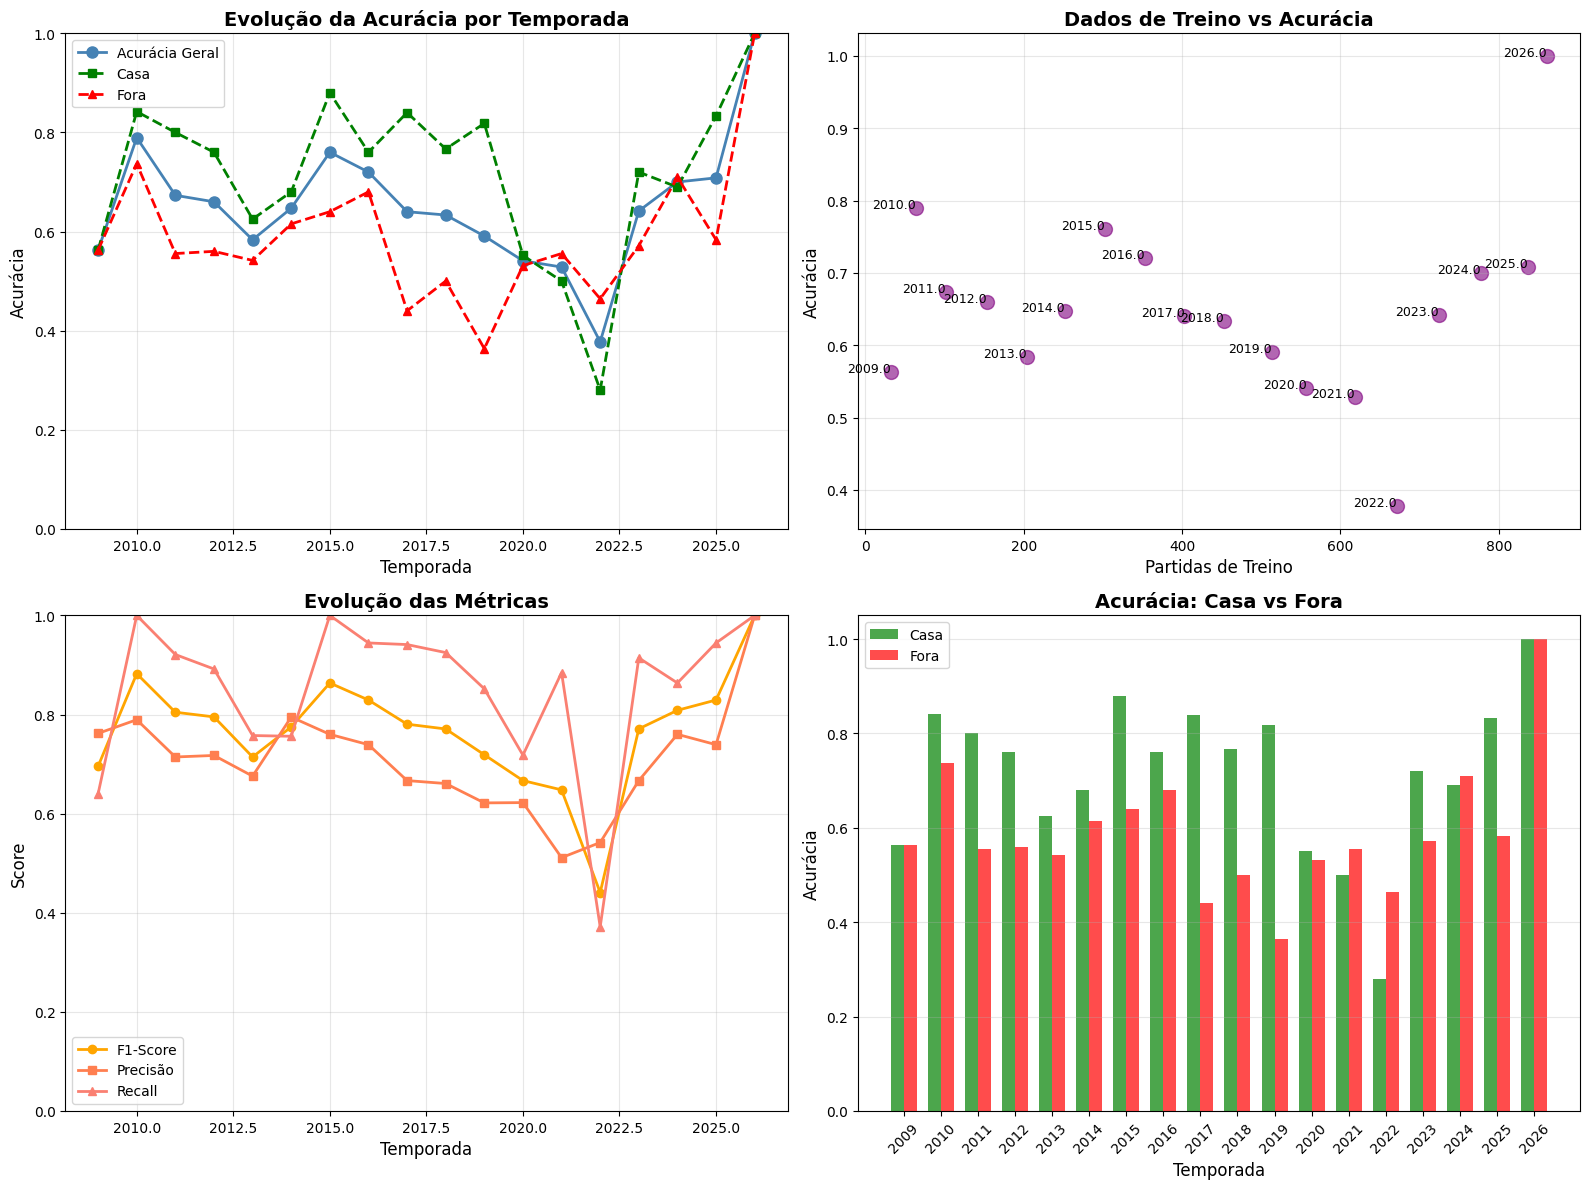

Gráfico de evolução temporal gerado


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Evolução da Acurácia por Temporada
axes[0, 0].plot(df_resultados_rf['temporada'], df_resultados_rf['accuracy'],
                marker='o', linewidth=2, markersize=8, color='steelblue', label='Acurácia Geral')
axes[0, 0].plot(df_resultados_rf['temporada'], df_resultados_rf['accuracy_casa'],
                marker='s', linewidth=2, markersize=6, color='green', label='Casa', linestyle='--')
axes[0, 0].plot(df_resultados_rf['temporada'], df_resultados_rf['accuracy_fora'],
                marker='^', linewidth=2, markersize=6, color='red', label='Fora', linestyle='--')
axes[0, 0].set_xlabel('Temporada', fontsize=12)
axes[0, 0].set_ylabel('Acurácia', fontsize=12)
axes[0, 0].set_title('Evolução da Acurácia por Temporada', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# Gráfico 2: Dados de Treino vs Acurácia
axes[0, 1].scatter(df_resultados_rf['n_treino'], df_resultados_rf['accuracy'],
                   s=100, alpha=0.6, color='purple')
for _, row in df_resultados_rf.iterrows():
    axes[0, 1].annotate(row['temporada'],
                       (row['n_treino'], row['accuracy']),
                       fontsize=9, ha='right')
axes[0, 1].set_xlabel('Partidas de Treino', fontsize=12)
axes[0, 1].set_ylabel('Acurácia', fontsize=12)
axes[0, 1].set_title('Dados de Treino vs Acurácia', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Gráfico 3: Evolução das Métricas
axes[1, 0].plot(df_resultados_rf['temporada'], df_resultados_rf['f1'],
                marker='o', linewidth=2, color='orange', label='F1-Score')
axes[1, 0].plot(df_resultados_rf['temporada'], df_resultados_rf['precision'],
                marker='s', linewidth=2, color='coral', label='Precisão')
axes[1, 0].plot(df_resultados_rf['temporada'], df_resultados_rf['recall'],
                marker='^', linewidth=2, color='salmon', label='Recall')
axes[1, 0].set_xlabel('Temporada', fontsize=12)
axes[1, 0].set_ylabel('Score', fontsize=12)
axes[1, 0].set_title('Evolução das Métricas', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# Gráfico 4: Acurácia Casa vs Fora
x = np.arange(len(df_resultados_rf))
width = 0.35
axes[1, 1].bar(x - width/2, df_resultados_rf['accuracy_casa'], width,
               label='Casa', color='green', alpha=0.7)
axes[1, 1].bar(x + width/2, df_resultados_rf['accuracy_fora'], width,
               label='Fora', color='red', alpha=0.7)
axes[1, 1].set_xlabel('Temporada', fontsize=12)
axes[1, 1].set_ylabel('Acurácia', fontsize=12)
axes[1, 1].set_title('Acurácia: Casa vs Fora', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(df_resultados_rf['temporada'], rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('evolucao_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico de evolução temporal gerado")

### Análise dos Resultados por Ano

In [ ]:
print("\n" + "="*80)
print("RESULTADOS DETALHADOS POR ANO")
print("="*80)

for _, row in df_resultados_rf.iterrows():
    print(f"\nTemporada {row['temporada']}")
    print(f"  Dados de treino: {row['n_treino']} partidas")
    print(f"  Dados de teste: {row['n_teste']} partidas")
    print(f"  Acurácia Geral: {row['accuracy']:.1%}")
    print(f"  Precisão: {row['precision']:.1%}")
    print(f"  Recall: {row['recall']:.1%}")
    print(f"  F1-Score: {row['f1']:.1%}")
    print(f"  Acurácia Casa: {row['accuracy_casa']:.1%}")
    print(f"  Acurácia Fora: {row['accuracy_fora']:.1%}")

print("\n" + "="*80)
print("ESTATÍSTICAS GLOBAIS")
print("="*80)

print(f"\nAcurácia Média: {df_resultados_rf['accuracy'].mean():.1%}")
print(f"Desvio Padrão: {df_resultados_rf['accuracy'].std():.1%}")
print(f"Acurácia Mínima: {df_resultados_rf['accuracy'].min():.1%} (Temporada {df_resultados_rf.loc[df_resultados_rf['accuracy'].idxmin(), 'temporada']})")
print(f"Acurácia Máxima: {df_resultados_rf['accuracy'].max():.1%} (Temporada {df_resultados_rf.loc[df_resultados_rf['accuracy'].idxmax(), 'temporada']})")

print(f"\nF1-Score Médio: {df_resultados_rf['f1'].mean():.1%}")
print(f"Precisão Média: {df_resultados_rf['precision'].mean():.1%}")
print(f"Recall Médio: {df_resultados_rf['recall'].mean():.1%}")

print(f"\nAcurácia Média Casa: {df_resultados_rf['accuracy_casa'].mean():.1%}")
print(f"Acurácia Média Fora: {df_resultados_rf['accuracy_fora'].mean():.1%}")
print(f"Diferença Casa-Fora: {(df_resultados_rf['accuracy_casa'].mean() - df_resultados_rf['accuracy_fora'].mean())*100:+.1f}pp")


RESULTADOS DETALHADOS POR ANO

Temporada 2009.0
  Dados de treino: 32.0 partidas
  Dados de teste: 32.0 partidas
  Acurácia Geral: 56.2%
  Precisão: 76.2%
  Recall: 64.0%
  F1-Score: 69.6%
  Acurácia Casa: 56.2%
  Acurácia Fora: 56.2%

Temporada 2010.0
  Dados de treino: 64.0 partidas
  Dados de teste: 38.0 partidas
  Acurácia Geral: 78.9%
  Precisão: 78.9%
  Recall: 100.0%
  F1-Score: 88.2%
  Acurácia Casa: 84.2%
  Acurácia Fora: 73.7%

Temporada 2011.0
  Dados de treino: 102.0 partidas
  Dados de teste: 52.0 partidas
  Acurácia Geral: 67.3%
  Precisão: 71.4%
  Recall: 92.1%
  F1-Score: 80.5%
  Acurácia Casa: 80.0%
  Acurácia Fora: 55.6%

Temporada 2012.0
  Dados de treino: 154.0 partidas
  Dados de teste: 50.0 partidas
  Acurácia Geral: 66.0%
  Precisão: 71.7%
  Recall: 89.2%
  F1-Score: 79.5%
  Acurácia Casa: 76.0%
  Acurácia Fora: 56.0%

Temporada 2013.0
  Dados de treino: 204.0 partidas
  Dados de teste: 48.0 partidas
  Acurácia Geral: 58.3%
  Precisão: 67.6%
  Recall: 75.8%
  F1